## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import sys
import textwrap
from typing import Any, Dict, List, Type
from IPython.display import display
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Move working directory to project root
os.chdir("..")
# Make project root importable
sys.path.insert(0, os.getcwd())
from src import *
from src import mlflow_helper

## 2. Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv('./data/hand_landmarks_data.csv')

# Basic info
print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (25675, 64)

First 5 rows:


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [4]:
# Statistical summary
df.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,z18,x19,y19,z19,x20,y20,z20,x21,y21,z21
count,25675.000000,25675.000000,2.567500e+04,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,...,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000,25675.000000
mean,201.958632,260.158527,1.272461e-07,202.517395,252.115322,-0.009465,202.862981,240.645966,-0.015946,203.025267,...,-0.024129,201.792374,227.455597,-0.033751,201.811275,227.802576,-0.032208,201.874802,227.807287,-0.028828
std,90.500333,76.533210,2.737932e-07,84.770933,75.384691,0.010376,80.412089,74.721921,0.013973,79.647588,...,0.015658,94.046497,77.231210,0.020453,93.664595,78.441253,0.020877,93.547017,79.963438,0.021136
min,-36.050926,45.722923,-2.029986e-06,7.184681,51.256840,-0.096630,25.114323,45.489950,-0.155846,23.446341,...,-0.201897,0.198635,20.146784,-0.286821,3.278137,32.158108,-0.286470,-4.537216,23.226204,-0.262047
25%,124.110329,205.815950,-5.243216e-08,130.535929,197.999625,-0.015199,136.711035,187.018583,-0.023020,138.905817,...,-0.030728,126.828913,172.720392,-0.042726,126.887403,172.345467,-0.041957,126.356627,172.083794,-0.039220
50%,199.667847,255.181793,1.497277e-07,199.979530,247.113892,-0.008737,200.092758,235.776978,-0.014231,200.482040,...,-0.020969,197.579865,221.781479,-0.029942,197.591736,222.381149,-0.028510,197.453270,222.485229,-0.025269
75%,266.428482,304.991663,2.989988e-07,261.147457,296.850769,-0.002783,255.876354,284.925993,-0.007134,254.622768,...,-0.013661,268.103920,273.190765,-0.019987,267.745743,274.196884,-0.017971,267.324657,275.805222,-0.014294
max,633.556020,781.674469,1.876254e-06,606.232386,751.869416,0.076365,598.541348,719.365010,0.094131,607.999801,...,0.031774,632.923029,779.419948,0.078105,638.134761,760.854103,0.104580,641.788521,760.554894,0.118668


In [5]:
# Check for missing values
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

x1       0
y1       0
z1       0
x2       0
y2       0
        ..
z20      0
x21      0
y21      0
z21      0
label    0
Length: 64, dtype: int64

Total missing: 0


In [6]:
# Check if there are duplicates in the data
df[df.duplicated()]

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label


In [7]:
# Class distribution
label_counts = df['label'].value_counts()
print('Class Distribution:')
print(label_counts)
print(f'\nNumber of unique classes: {df["label"].nunique()}')

Class Distribution:
label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64

Number of unique classes: 18


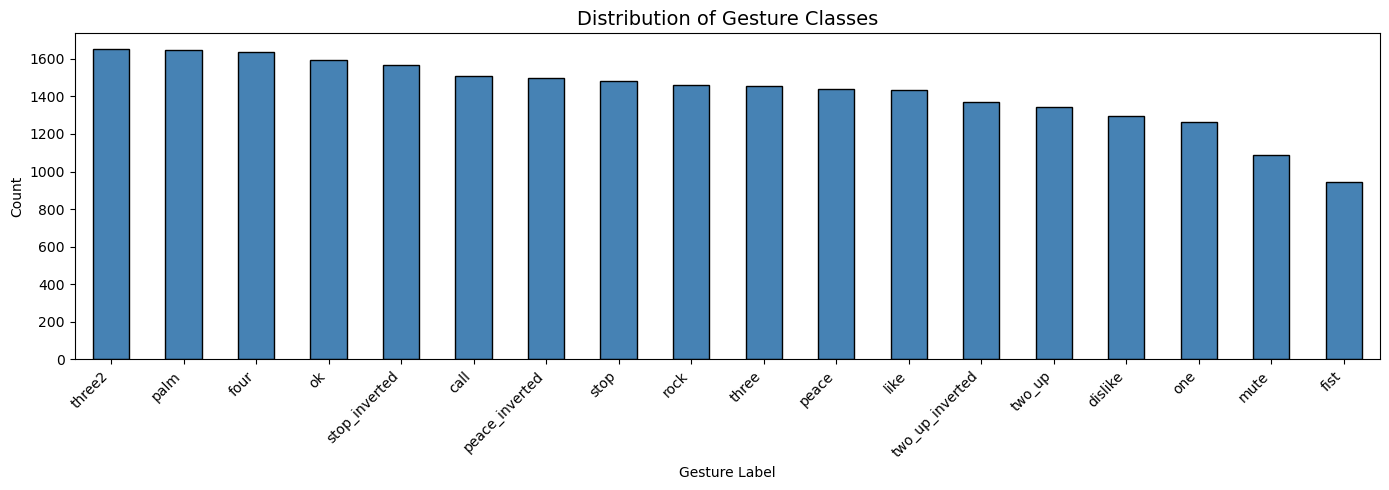

In [8]:
# Class distribution bar plot
plt.figure(figsize=(14, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Gesture Classes', fontsize=14)
plt.xlabel('Gesture Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Data Visualization

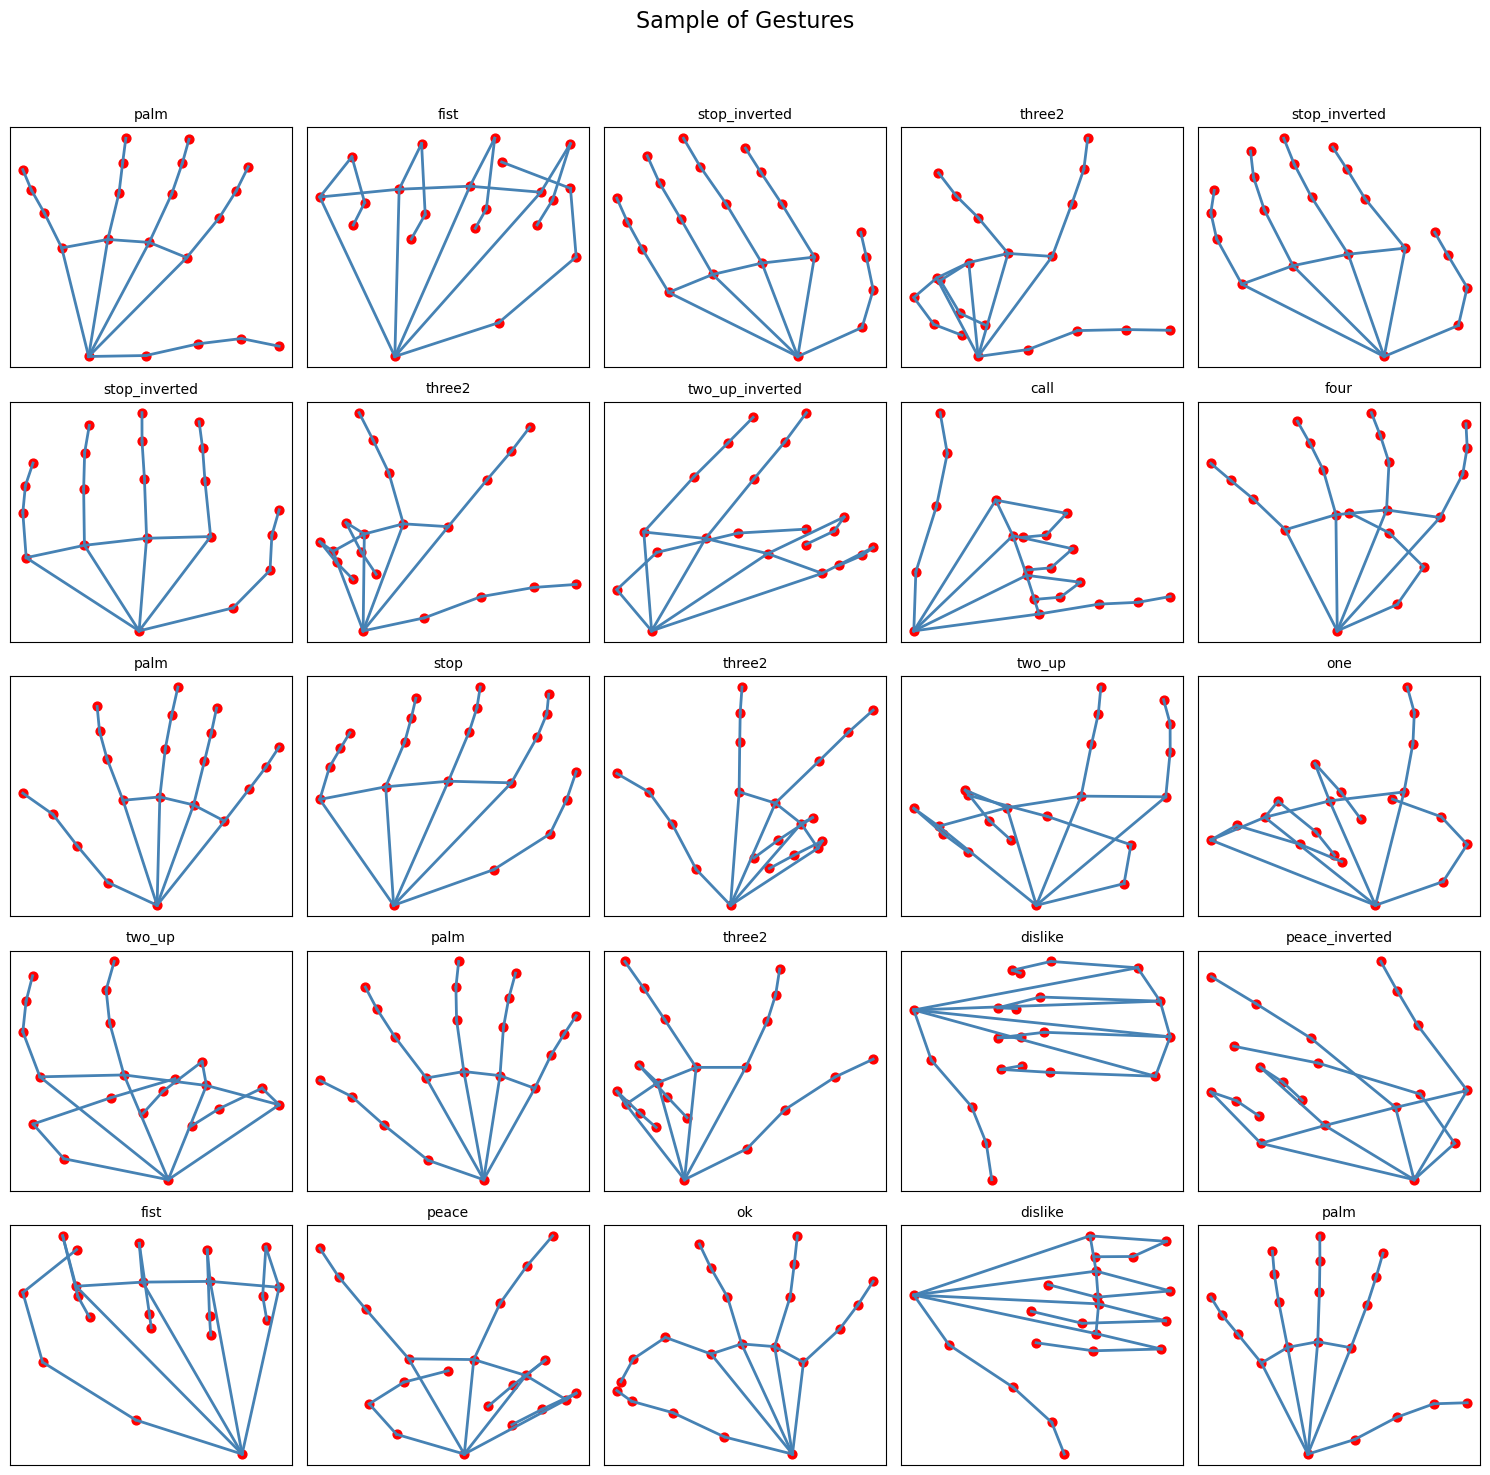

In [9]:
plot_gesture_grid(df=df,n_rows=5,n_cols=5)

## 4. Data Preprocessing

In this section, we clean, normalize, and split the data into training and test sets.

In [10]:
# Features and target
X = df.drop(columns=['label'])
y = df['label']

# Apply the required normalization (X/Y only)
X_normalized = normalize_hand_xy(X)

In [11]:
# Initialize Encoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Print the mapping
for i, label in enumerate(encoder.classes_):
    print(f"{i}: {label}")

0: call
1: dislike
2: fist
3: four
4: like
5: mute
6: ok
7: one
8: palm
9: peace
10: peace_inverted
11: rock
12: stop
13: stop_inverted
14: three
15: three2
16: two_up
17: two_up_inverted


In [12]:
# Split data to train and test_validate
X_train, X_test_validate, y_train, y_test_validate = train_test_split(
    X_normalized, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test_Validation shape:', X_test_validate.shape, y_test_validate.shape)

Train shape: (20540, 63) (20540,)
Test_Validation shape: (5135, 63) (5135,)


In [13]:
# Split test_validate to validation and test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_test_validate, 
    y_test_validate, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_test_validate
)

print('Validation shape:', X_validation.shape, y_validation.shape)
print('Test shape:', X_test.shape, y_test.shape)

Validation shape: (2567, 63) (2567,)
Test shape: (2568, 63) (2568,)


## 5. Modeling and Evaluation

In [14]:
mlflow_helper.set_experiment(name="Hand_Gesuter_Classification", tracking_uri="file:./mlruns")

c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


##### `1. Random Forest`


Random Forest | Params: {'n_estimators': 100, 'max_depth': None, 'random_state': 42, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.9805220101285548, 'precision_weighted': 0.9807980483006012, 'recall_weighted': 0.9805220101285548, 'f1_weighted': 0.9805938810171742}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9762461059190031, 'precision_weighted': 0.9764680501863461, 'recall_weighted': 0.9762461059190031, 'f1_weighted': 0.976281148955297}


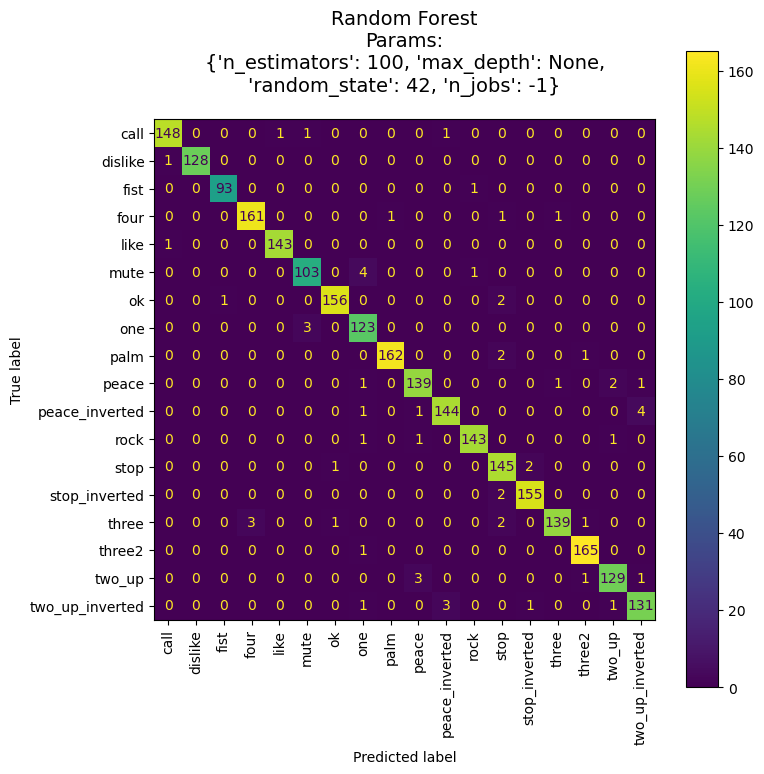


Random Forest | Params: {'n_estimators': 300, 'max_depth': 30, 'random_state': 42, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.9805220101285548, 'precision_weighted': 0.9808192919189923, 'recall_weighted': 0.9805220101285548, 'f1_weighted': 0.9805948638352656}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9766355140186916, 'precision_weighted': 0.9769106065516235, 'recall_weighted': 0.9766355140186916, 'f1_weighted': 0.9766831974572368}


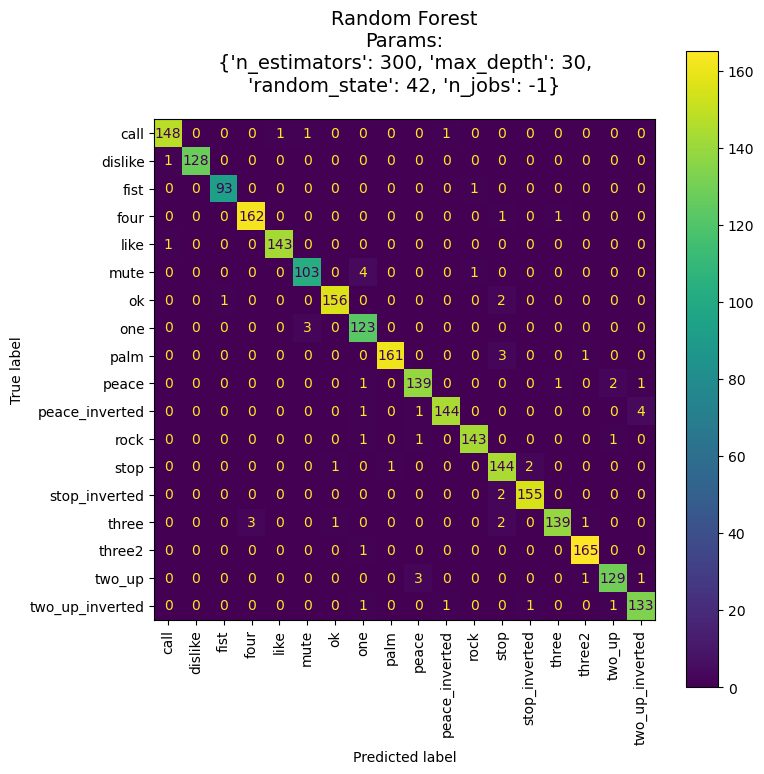


Random Forest | Params: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 5, 'random_state': 42, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 0.9993184031158715, 'precision_weighted': 0.9993194883534094, 'recall_weighted': 0.9993184031158715, 'f1_weighted': 0.9993184135838107}

--- Validation Metrics ---
{'accuracy': 0.9809115699259836, 'precision_weighted': 0.9811524301887369, 'recall_weighted': 0.9809115699259836, 'f1_weighted': 0.9809679662586623}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9758566978193146, 'precision_weighted': 0.9760702100273584, 'recall_weighted': 0.9758566978193146, 'f1_weighted': 0.975895737173389}


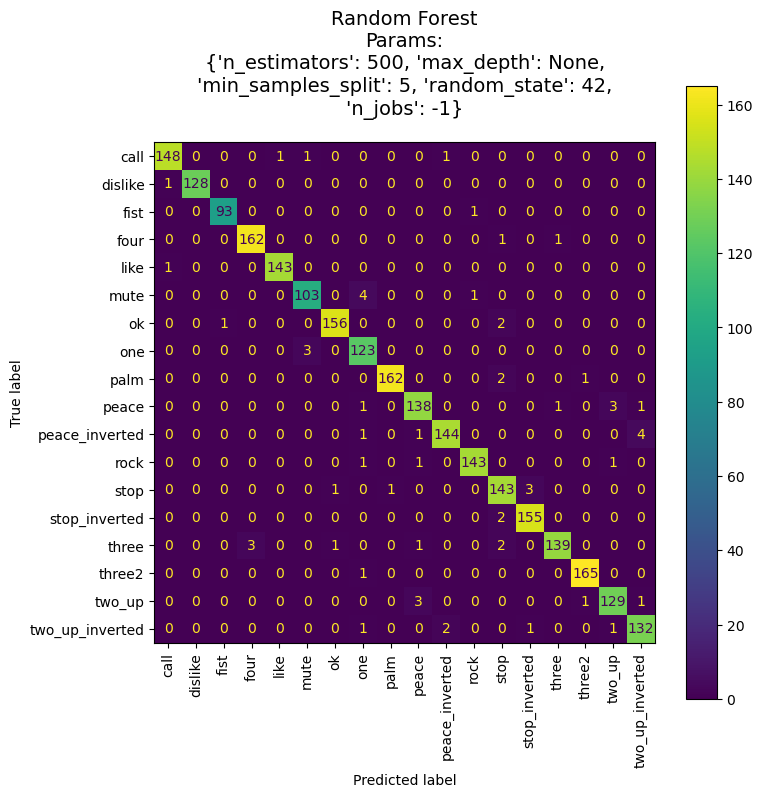

In [15]:
rf_param_grid = [
    {"n_estimators": 100, "max_depth": None, "random_state": 42, "n_jobs": -1},
    {"n_estimators": 300, "max_depth": 30, "random_state": 42, "n_jobs": -1},
    {"n_estimators": 500, "max_depth": None, "min_samples_split": 5, "random_state": 42, "n_jobs": -1},
]

rf_results = train_and_evaluate_models(
    model_class=RandomForestClassifier,
    param_grid=rf_param_grid,
    model_name="Random Forest",
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    encoder=encoder,
)

Log each Random Forest run

In [16]:
log_runs_to_mlflow(
    results=rf_results,
    model_family="RandomForest",
    X_train=X_train,
    X_validation=X_validation,
    X_test=X_test,
    y_test=y_test,
)

2026/02/26 16:53:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:53:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 16:53:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:53:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p



[[[RandomForest runs logged to MLflow]]]


##### `2. XGBoost`


XGBoost | Params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'multi:softmax', 'num_class': 18, 'n_jobs': -1, 'tree_method': 'hist'}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.9828593689131282, 'precision_weighted': 0.9829729602685611, 'recall_weighted': 0.9828593689131282, 'f1_weighted': 0.9828785052062221}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9816978193146417, 'precision_weighted': 0.9819059586829693, 'recall_weighted': 0.9816978193146417, 'f1_weighted': 0.981734311641047}


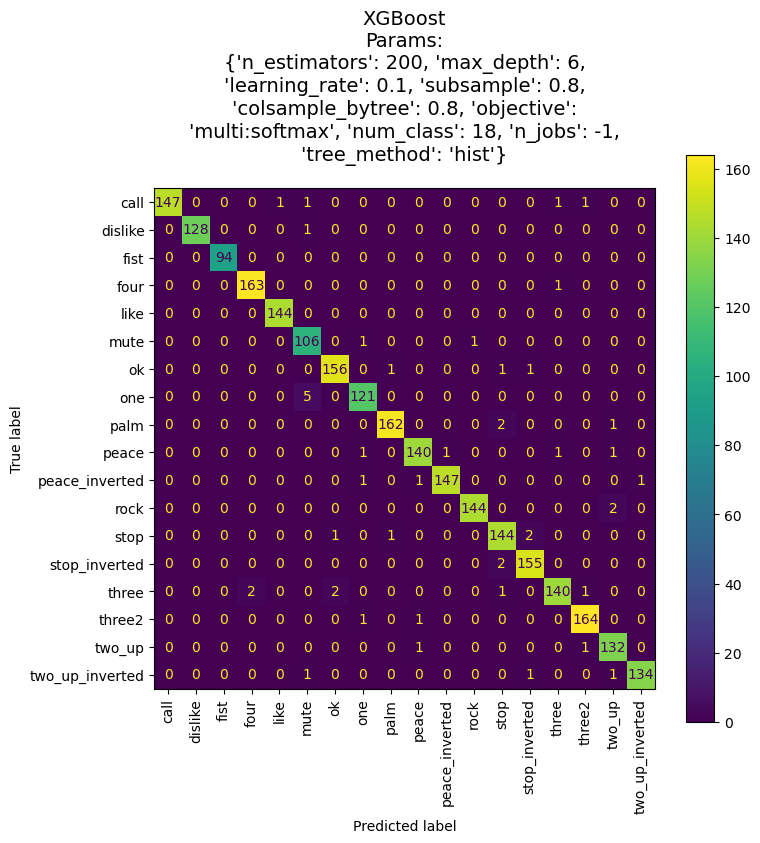


XGBoost | Params: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'objective': 'multi:softmax', 'num_class': 18, 'n_jobs': -1, 'tree_method': 'hist'}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.983248928710557, 'precision_weighted': 0.9834010855710884, 'recall_weighted': 0.983248928710557, 'f1_weighted': 0.9832743092340147}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9813084112149533, 'precision_weighted': 0.9815322911932497, 'recall_weighted': 0.9813084112149533, 'f1_weighted': 0.9813312378884704}


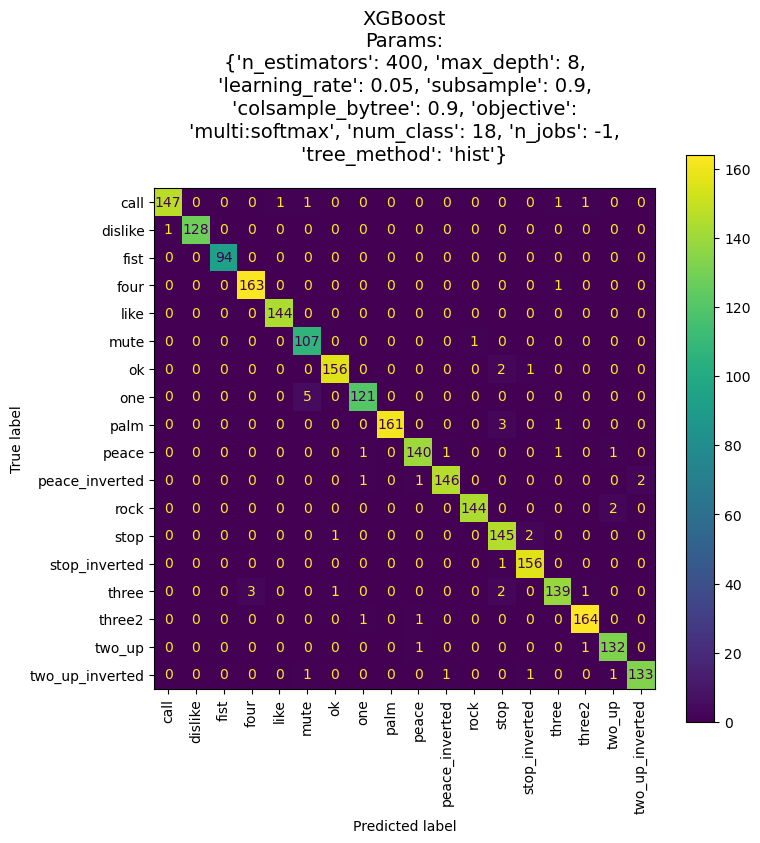

In [17]:
xgb_param_grid = [
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.1, "subsample": 0.8, "colsample_bytree": 0.8, "objective": "multi:softmax", "num_class": len(encoder.classes_), "n_jobs": -1, "tree_method": "hist"},
    {"n_estimators": 400, "max_depth": 8, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.9, "objective": "multi:softmax", "num_class": len(encoder.classes_), "n_jobs": -1, "tree_method": "hist"},
]

xgb_results = train_and_evaluate_models(
    model_class=XGBClassifier,
    param_grid=xgb_param_grid,
    model_name="XGBoost",
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    encoder=encoder,
)

Log each XGBoost run

In [18]:
log_runs_to_mlflow(
    results=xgb_results,
    model_family="XGBoost",
    X_train=X_train,
    X_validation=X_validation,
    X_test=X_test,
    y_test=y_test,
)

2026/02/26 16:54:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:54:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 16:54:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:54:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p



[[[XGBoost runs logged to MLflow]]]


#### `3. Logistic Regression`

c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Logistic Regression | Params: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 0.8572541382667965, 'precision_weighted': 0.857868740408164, 'recall_weighted': 0.8572541382667965, 'f1_weighted': 0.8565116412652063}

--- Validation Metrics ---
{'accuracy': 0.8679392286716011, 'precision_weighted': 0.8680591690407815, 'recall_weighted': 0.8679392286716011, 'f1_weighted': 0.866739527835607}

--- Test Metrics (FINAL) ---
{'accuracy': 0.8469626168224299, 'precision_weighted': 0.8485028875684898, 'recall_weighted': 0.8469626168224299, 'f1_weighted': 0.8467324825551401}


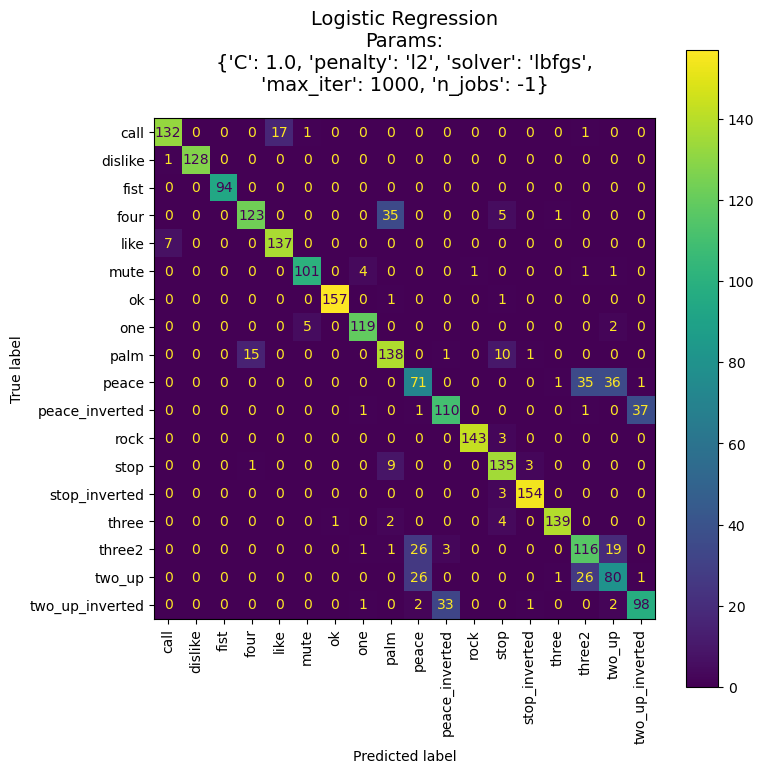

c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Logistic Regression | Params: {'C': 0.5, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 0.8411879259980526, 'precision_weighted': 0.841719394256424, 'recall_weighted': 0.8411879259980526, 'f1_weighted': 0.8395462097466818}

--- Validation Metrics ---
{'accuracy': 0.8507985975847293, 'precision_weighted': 0.8507586758128781, 'recall_weighted': 0.8507985975847293, 'f1_weighted': 0.8489539989286852}

--- Test Metrics (FINAL) ---
{'accuracy': 0.8341121495327103, 'precision_weighted': 0.835563429374582, 'recall_weighted': 0.8341121495327103, 'f1_weighted': 0.8334901136110322}


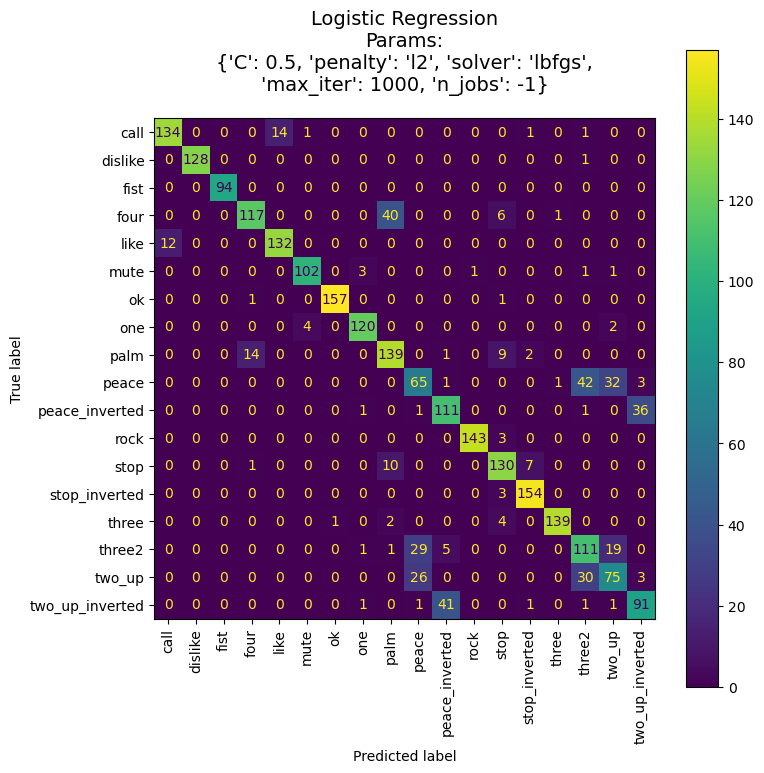

c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mazen\anaconda3\envs\hand_gesture_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Logistic Regression | Params: {'C': 2.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000, 'n_jobs': -1}

--- Train Metrics ---
{'accuracy': 0.8704479065238558, 'precision_weighted': 0.8708833746749456, 'recall_weighted': 0.8704479065238558, 'f1_weighted': 0.8700490674108975}

--- Validation Metrics ---
{'accuracy': 0.8776782236073237, 'precision_weighted': 0.8778992821527533, 'recall_weighted': 0.8776782236073237, 'f1_weighted': 0.8767890255705465}

--- Test Metrics (FINAL) ---
{'accuracy': 0.8605919003115264, 'precision_weighted': 0.8619813653373773, 'recall_weighted': 0.8605919003115264, 'f1_weighted': 0.8605629685033077}


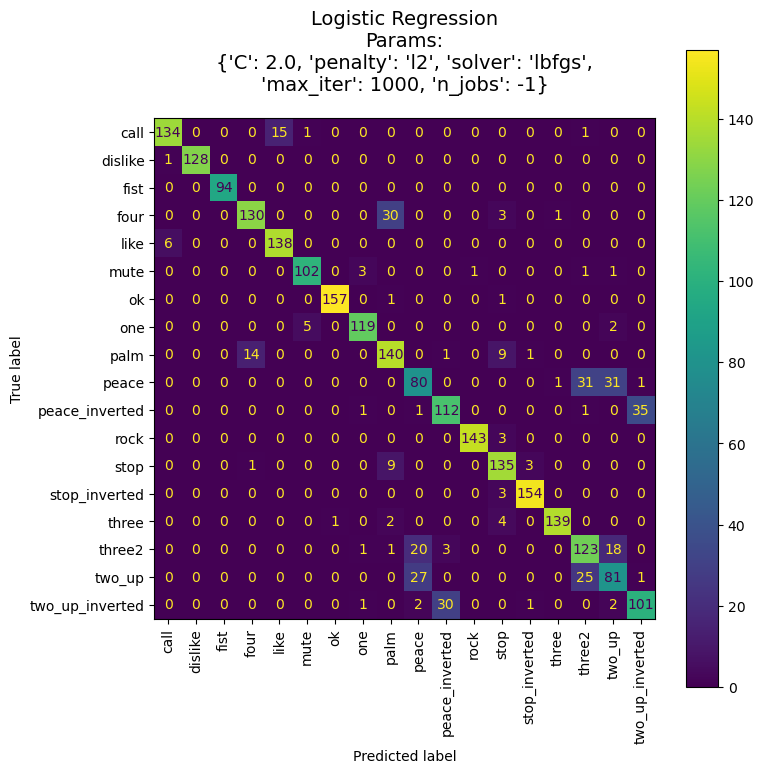

In [19]:
logreg_param_grid = [
    {"C": 1.0, "penalty": "l2", "solver": "lbfgs", "max_iter": 1000, "n_jobs": -1},
    {"C": 0.5, "penalty": "l2", "solver": "lbfgs", "max_iter": 1000, "n_jobs": -1},
    {"C": 2.0, "penalty": "l2", "solver": "lbfgs", "max_iter": 1000, "n_jobs": -1},
]

logreg_results = train_and_evaluate_models(
    model_class=LogisticRegression,
    param_grid=logreg_param_grid,
    model_name="Logistic Regression",
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    encoder=encoder,
)

Log each Logistic Regression run

In [20]:
log_runs_to_mlflow(
    results=logreg_results,
    model_family="LogisticRegression",
    X_train=X_train,
    X_validation=X_validation,
    X_test=X_test,
    y_test=y_test,
)

2026/02/26 16:54:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:54:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 16:54:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:54:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p



[[[LogisticRegression runs logged to MLflow]]]


#### `4. SVM`


SVM | Params: {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}

--- Train Metrics ---
{'accuracy': 0.9268743914313534, 'precision_weighted': 0.9288168266714629, 'recall_weighted': 0.9268743914313534, 'f1_weighted': 0.9270141311420164}

--- Validation Metrics ---
{'accuracy': 0.9368913128165174, 'precision_weighted': 0.9396192225061024, 'recall_weighted': 0.9368913128165174, 'f1_weighted': 0.9368250569298541}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9299065420560748, 'precision_weighted': 0.9323606641589667, 'recall_weighted': 0.9299065420560748, 'f1_weighted': 0.9299271120124717}


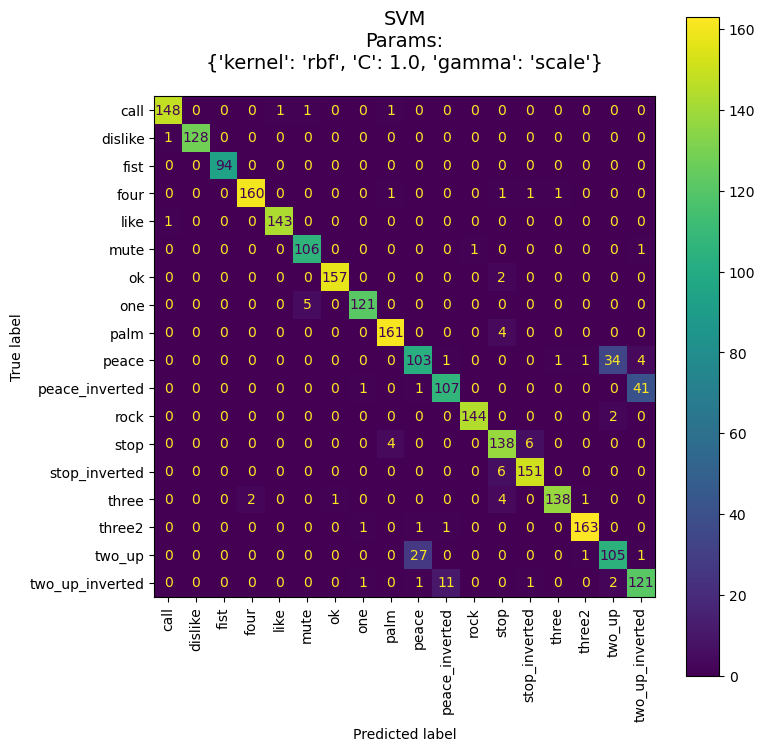


SVM | Params: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}

--- Train Metrics ---
{'accuracy': 0.9816455696202532, 'precision_weighted': 0.9819405292794336, 'recall_weighted': 0.9816455696202532, 'f1_weighted': 0.9816773994965607}

--- Validation Metrics ---
{'accuracy': 0.9801324503311258, 'precision_weighted': 0.9805461409492265, 'recall_weighted': 0.9801324503311258, 'f1_weighted': 0.9801471771367548}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9762461059190031, 'precision_weighted': 0.9766727117578248, 'recall_weighted': 0.9762461059190031, 'f1_weighted': 0.976264257413414}


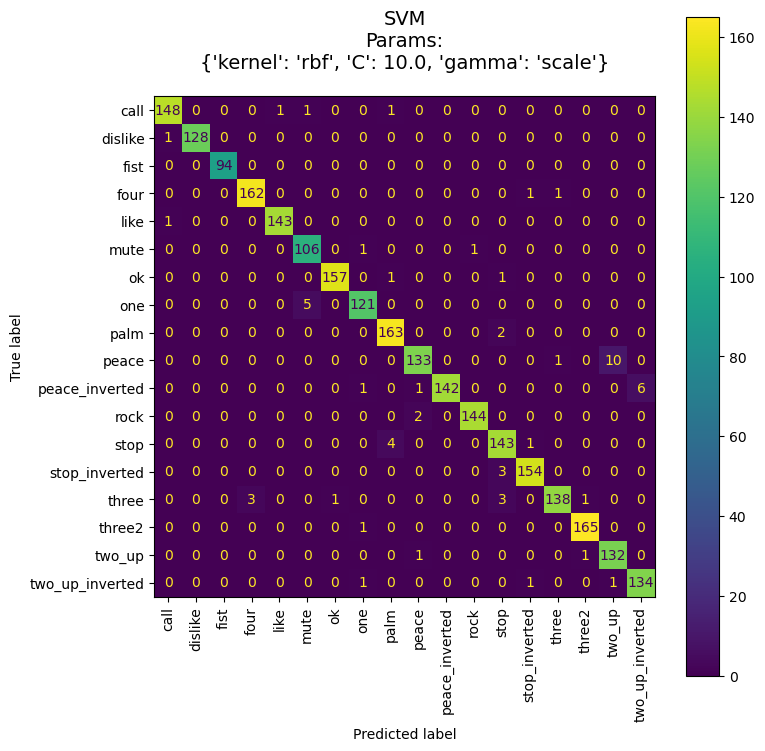


SVM | Params: {'kernel': 'linear', 'C': 1.0}

--- Train Metrics ---
{'accuracy': 0.8674780915287245, 'precision_weighted': 0.8684757897846374, 'recall_weighted': 0.8674780915287245, 'f1_weighted': 0.8668574616488581}

--- Validation Metrics ---
{'accuracy': 0.8757304246201792, 'precision_weighted': 0.8773577013569503, 'recall_weighted': 0.8757304246201792, 'f1_weighted': 0.8749286096296301}

--- Test Metrics (FINAL) ---
{'accuracy': 0.8656542056074766, 'precision_weighted': 0.8670545419054342, 'recall_weighted': 0.8656542056074766, 'f1_weighted': 0.8654259948238903}


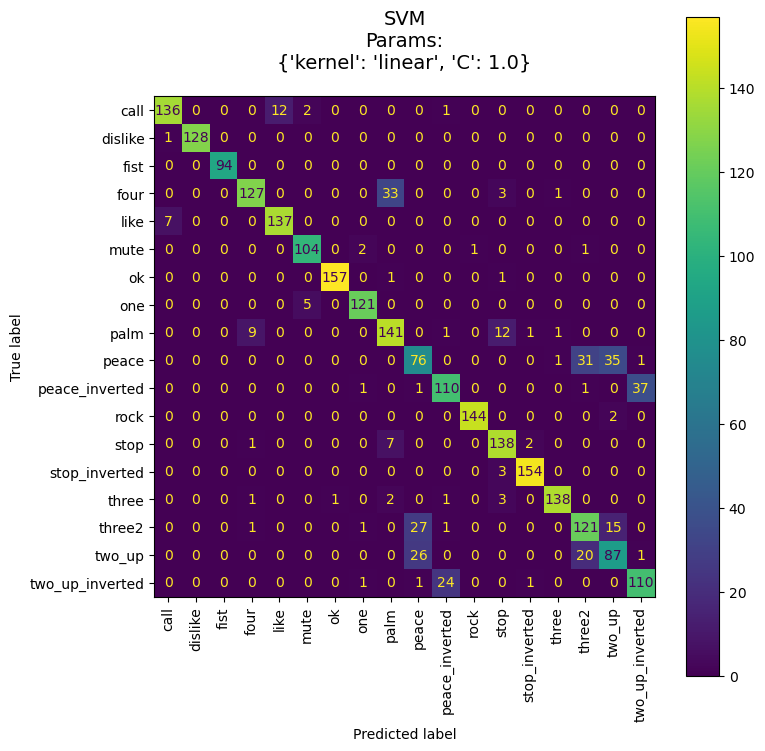

In [21]:
svm_param_grid = [
    {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
    {"kernel": "rbf", "C": 10.0, "gamma": "scale"},
    {"kernel": "linear", "C": 1.0},
]

svm_results = train_and_evaluate_models(
    model_class=SVC,
    param_grid=svm_param_grid,
    model_name="SVM",
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    encoder=encoder,
)

Log each SVM run

In [22]:
log_runs_to_mlflow(
    results=svm_results,
    model_family="SVM",
    X_train=X_train,
    X_validation=X_validation,
    X_test=X_test,
    y_test=y_test,
)

2026/02/26 16:55:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:55:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 16:55:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:55:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p



[[[SVM runs logged to MLflow]]]


#### `5. KNN`


KNN | Params: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'minkowski'}

--- Train Metrics ---
{'accuracy': 0.9854430379746836, 'precision_weighted': 0.9855018034236555, 'recall_weighted': 0.9854430379746836, 'f1_weighted': 0.9854430006395624}

--- Validation Metrics ---
{'accuracy': 0.9781846513439812, 'precision_weighted': 0.978381373751097, 'recall_weighted': 0.9781846513439812, 'f1_weighted': 0.9782327438686169}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9766355140186916, 'precision_weighted': 0.9769838616548816, 'recall_weighted': 0.9766355140186916, 'f1_weighted': 0.9766602380332676}


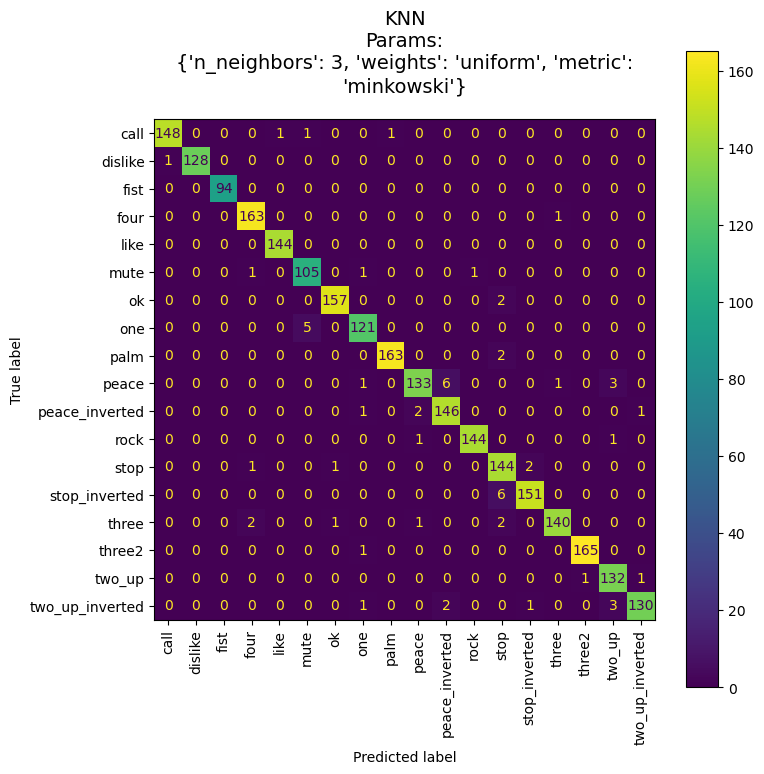


KNN | Params: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'minkowski'}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.9801324503311258, 'precision_weighted': 0.9802967636681011, 'recall_weighted': 0.9801324503311258, 'f1_weighted': 0.9801761988353185}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9758566978193146, 'precision_weighted': 0.9762065808935647, 'recall_weighted': 0.9758566978193146, 'f1_weighted': 0.9758759493792656}


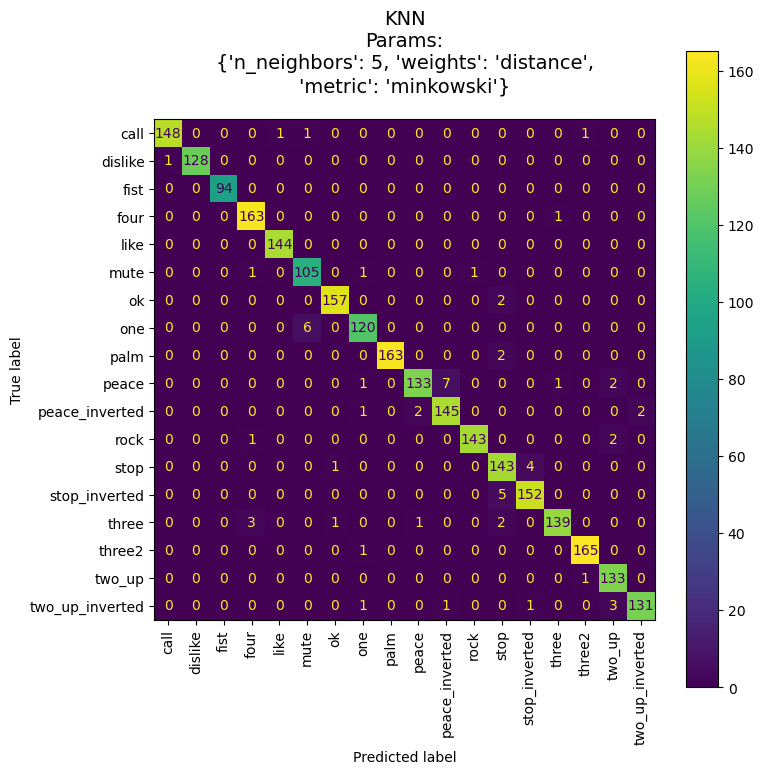


KNN | Params: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski'}

--- Train Metrics ---
{'accuracy': 1.0, 'precision_weighted': 1.0, 'recall_weighted': 1.0, 'f1_weighted': 1.0}

--- Validation Metrics ---
{'accuracy': 0.9762368523568368, 'precision_weighted': 0.9765179654198813, 'recall_weighted': 0.9762368523568368, 'f1_weighted': 0.9762949944769165}

--- Test Metrics (FINAL) ---
{'accuracy': 0.9754672897196262, 'precision_weighted': 0.9758299682956463, 'recall_weighted': 0.9754672897196262, 'f1_weighted': 0.9755008484225577}


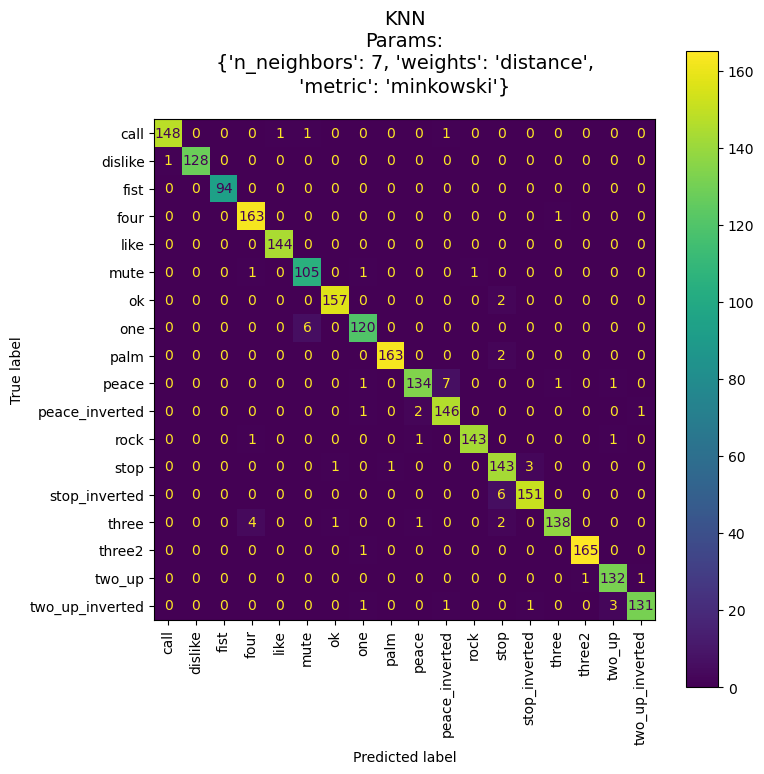

In [23]:
knn_param_grid = [
    {"n_neighbors": 3, "weights": "uniform", "metric": "minkowski"},
    {"n_neighbors": 5, "weights": "distance", "metric": "minkowski"},
    {"n_neighbors": 7, "weights": "distance", "metric": "minkowski"},
]

knn_results = train_and_evaluate_models(
    model_class=KNeighborsClassifier,
    param_grid=knn_param_grid,
    model_name="KNN",
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    encoder=encoder,
)

Log each KNN run

In [24]:
log_runs_to_mlflow(
    results=knn_results,
    model_family="KNN",
    X_train=X_train,
    X_validation=X_validation,
    X_test=X_test,
    y_test=y_test,
)

2026/02/26 16:55:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:55:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/26 16:56:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/26 16:56:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p



[[[KNN runs logged to MLflow]]]


#### `Model Comparison Leaderboard`

In [25]:
# Collect all results into one list
all_results = (
    rf_results
    + xgb_results
    + logreg_results
    + svm_results
    + knn_results
)

# Build rows
rows = []
for r in all_results:
    rows.append({
        "Model": r["model_name"],
        "Params": str(r["params"]),
        "Train Acc": r["metrics_train"]["accuracy"],
        "Train F1": r["metrics_train"]["f1_weighted"],
        "Val Acc": r["metrics_val"]["accuracy"],
        "Val F1": r["metrics_val"]["f1_weighted"],
        "Test Acc": r["metrics_test"]["accuracy"],
        "Test F1": r["metrics_test"]["f1_weighted"],
    })

# Create dataframe
leaderboard_df = pd.DataFrame(rows)

# Sort by best metric
leaderboard_df = leaderboard_df.sort_values(
    "Test F1", ascending=False
).reset_index(drop=True)

# Add rank
leaderboard_df.insert(0, "Rank", leaderboard_df.index + 1)

print("\n MODEL LEADERBOARD (sorted by Test F1)\n")

# Pretty display
display(
    leaderboard_df.style
    .hide(axis="index")
    .format("{:.4f}", subset=[
        "Train Acc", "Train F1",
        "Val Acc", "Val F1",
        "Test Acc", "Test F1"
    ])
    .background_gradient(subset=["Test F1"], cmap="Greens")
    .background_gradient(subset=["Val F1"], cmap="Blues")
)

# Print Winner
winner = leaderboard_df.iloc[0]

print("\n" + "=" * 30)
print("WINNER MODEL")
print("=" * 30)
print(f"Model      : {winner['Model']}")
print(f"Test F1    : {winner['Test F1']:.4f}")
print(f"Test Acc   : {winner['Test Acc']:.4f}")
print(f"Parameters : {winner['Params']}")
print("=" * 30)


 MODEL LEADERBOARD (sorted by Test F1)



Rank,Model,Params,Train Acc,Train F1,Val Acc,Val F1,Test Acc,Test F1
1,XGBoost,"{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'multi:softmax', 'num_class': 18, 'n_jobs': -1, 'tree_method': 'hist'}",1.0000,1.0000,0.9829,0.9829,0.9817,0.9817
2,XGBoost,"{'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'objective': 'multi:softmax', 'num_class': 18, 'n_jobs': -1, 'tree_method': 'hist'}",1.0000,1.0000,0.9832,0.9833,0.9813,0.9813
3,Random Forest,"{'n_estimators': 300, 'max_depth': 30, 'random_state': 42, 'n_jobs': -1}",1.0000,1.0000,0.9805,0.9806,0.9766,0.9767
4,KNN,"{'n_neighbors': 3, 'weights': 'uniform', 'metric': 'minkowski'}",0.9854,0.9854,0.9782,0.9782,0.9766,0.9767
5,Random Forest,"{'n_estimators': 100, 'max_depth': None, 'random_state': 42, 'n_jobs': -1}",1.0000,1.0000,0.9805,0.9806,0.9762,0.9763
6,SVM,"{'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale'}",0.9816,0.9817,0.9801,0.9801,0.9762,0.9763
7,Random Forest,"{'n_estimators': 500, 'max_depth': None, 'min_samples_split': 5, 'random_state': 42, 'n_jobs': -1}",0.9993,0.9993,0.9809,0.9810,0.9759,0.9759
8,KNN,"{'n_neighbors': 5, 'weights': 'distance', 'metric': 'minkowski'}",1.0000,1.0000,0.9801,0.9802,0.9759,0.9759
9,KNN,"{'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski'}",1.0000,1.0000,0.9762,0.9763,0.9755,0.9755
10,SVM,"{'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}",0.9269,0.9270,0.9369,0.9368,0.9299,0.9299



WINNER MODEL
Model      : XGBoost
Test F1    : 0.9817
Test Acc   : 0.9817
Parameters : {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'multi:softmax', 'num_class': 18, 'n_jobs': -1, 'tree_method': 'hist'}


`Saving Promoted Models`

In [26]:
# Rank 1 --> first XGBoost
best_xgb = xgb_results[0]

# Rank 3 --> Random Forest
rf_rank3 = rf_results[1]

In [27]:
os.makedirs("models", exist_ok=True)

# XGBoost (Production)
xgb_local_path = "models/HandGesture_XGBoost_Shallow.joblib"
joblib.dump(best_xgb["model"], xgb_local_path)
print(f"Saved: {xgb_local_path}")

# Random Forest (Staging)
rf_local_path = "models/HandGesture_RandomForest_Deep.joblib"
joblib.dump(rf_rank3["model"], rf_local_path, compress=3)
print(f"Saved: {rf_local_path}")

# Label Encoder (for inference)
encoder_path = "models/label_encoder.joblib"
joblib.dump(encoder, encoder_path)
print(f"Saved: {encoder_path}")

Saved: models/HandGesture_XGBoost_Shallow.joblib
Saved: models/HandGesture_RandomForest_Deep.joblib
Saved: models/label_encoder.joblib


`Register models on mlflow`

Registered XGBoost Shallow model and gave it an alias "Production".<br>
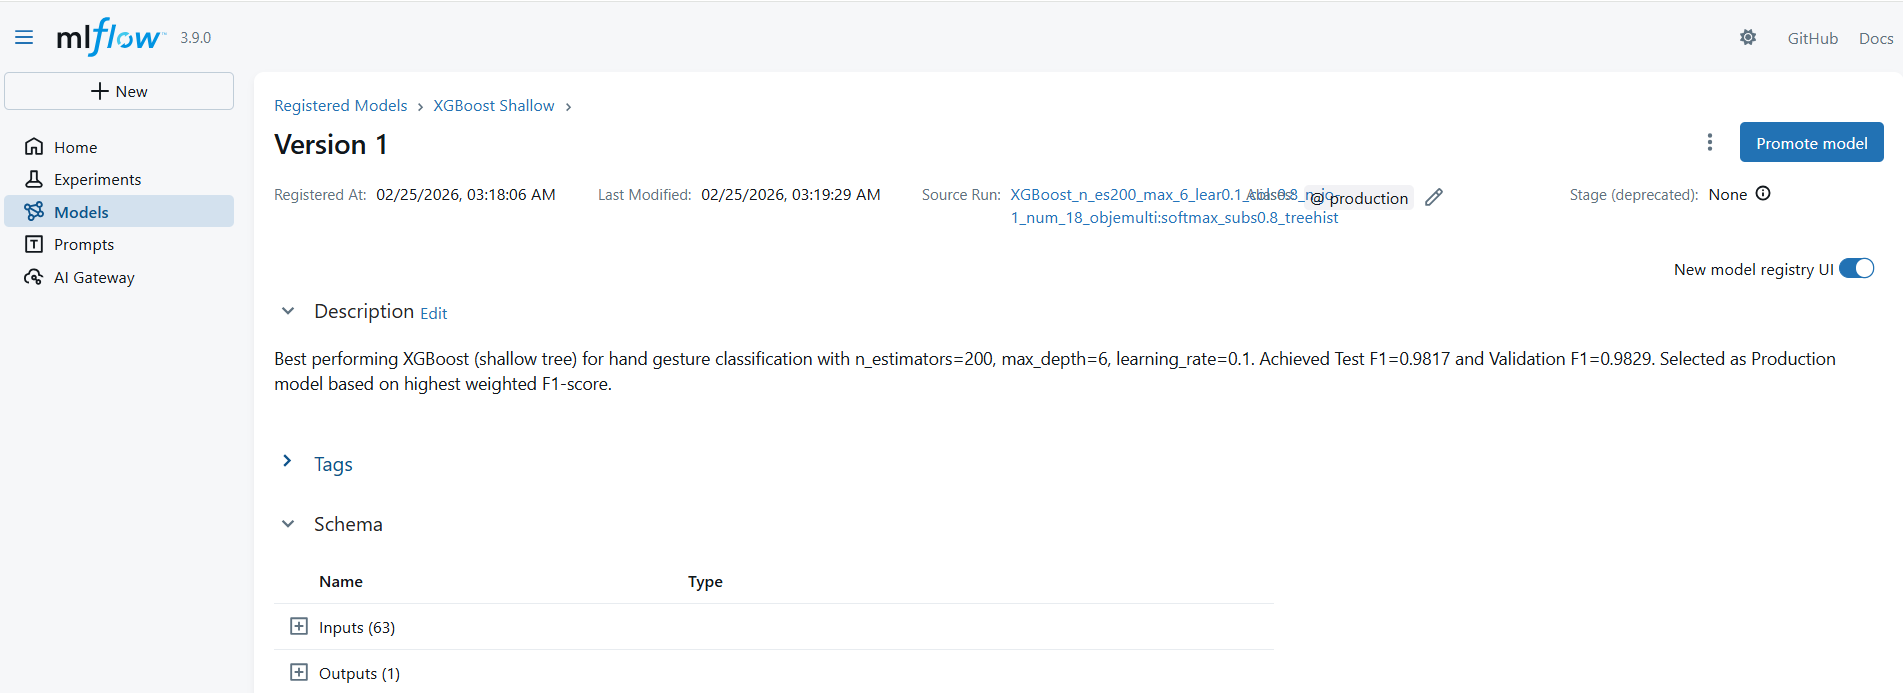

Registered Random Forest Deep model and gave it an alias "Staging".<br>
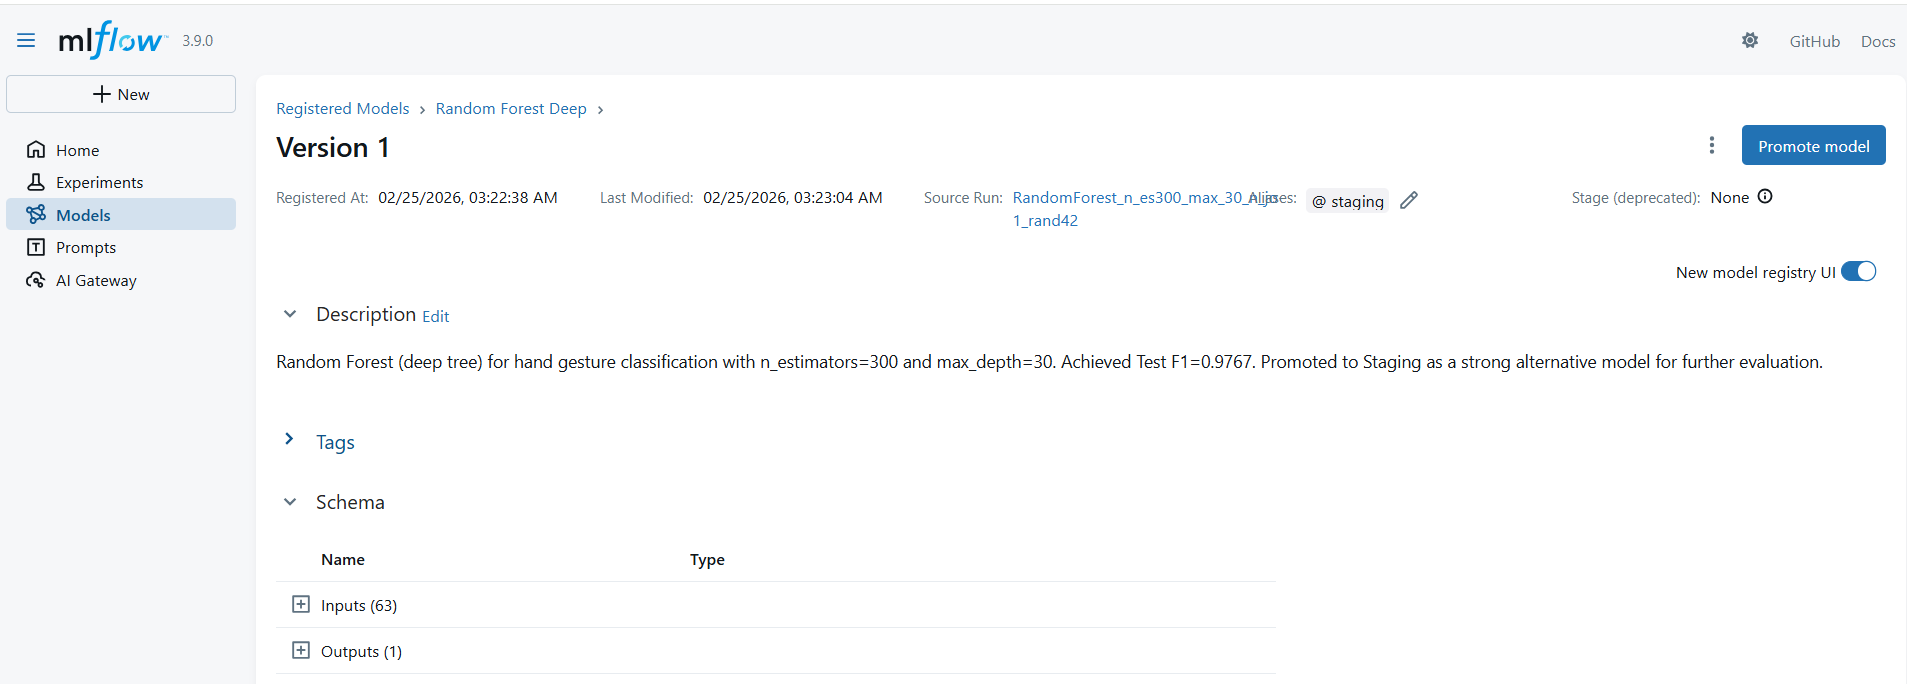